Shape del dataset: (1599, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
quality_class
0    744
1    638
2    217
Name: count, dtype: int64


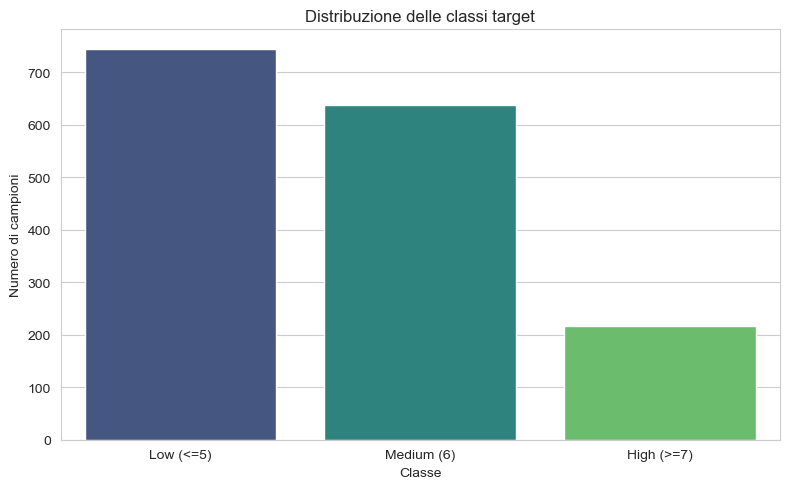

Numero di feature: 11
Feature: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Train set: (959, 11)
Validation set: (320, 11)
Test set: (320, 11)


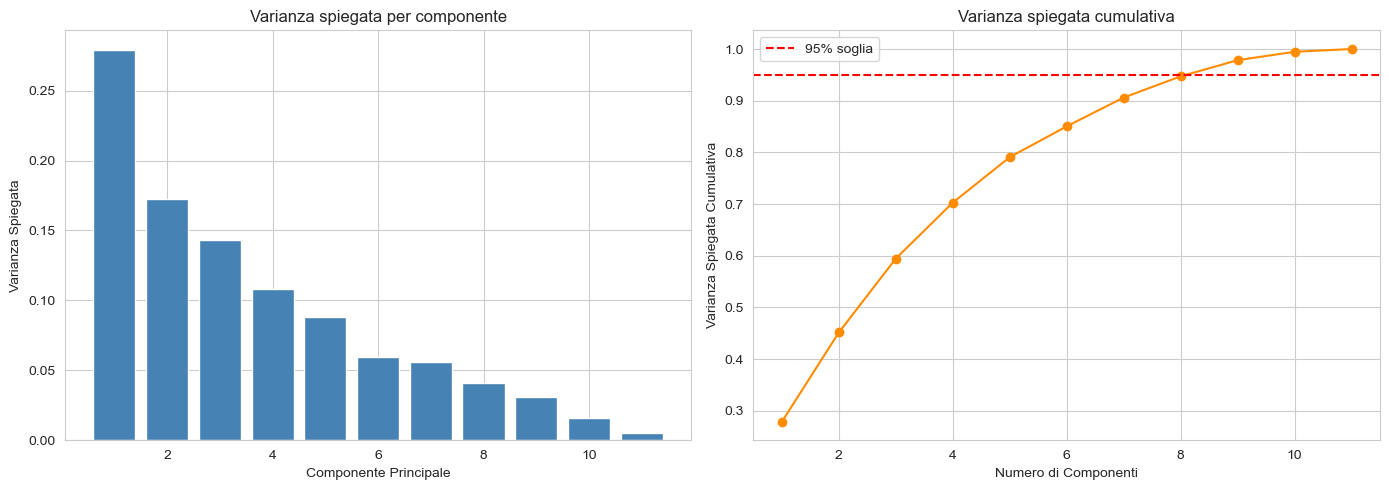

Numero di componenti necessarie per spiegare il 95% della varianza: 9


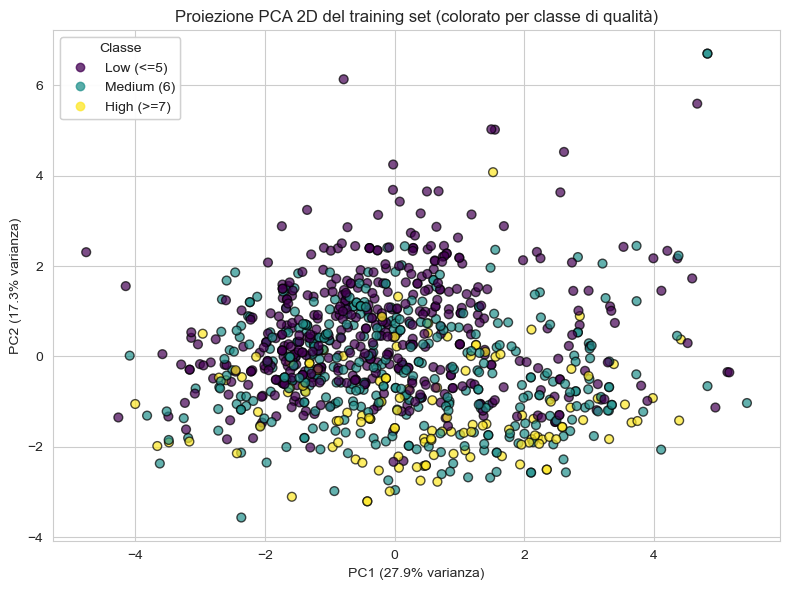

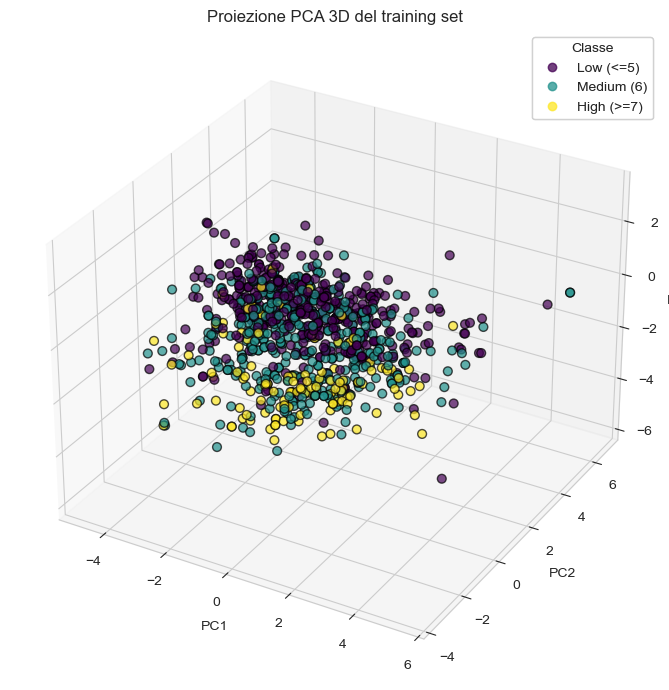

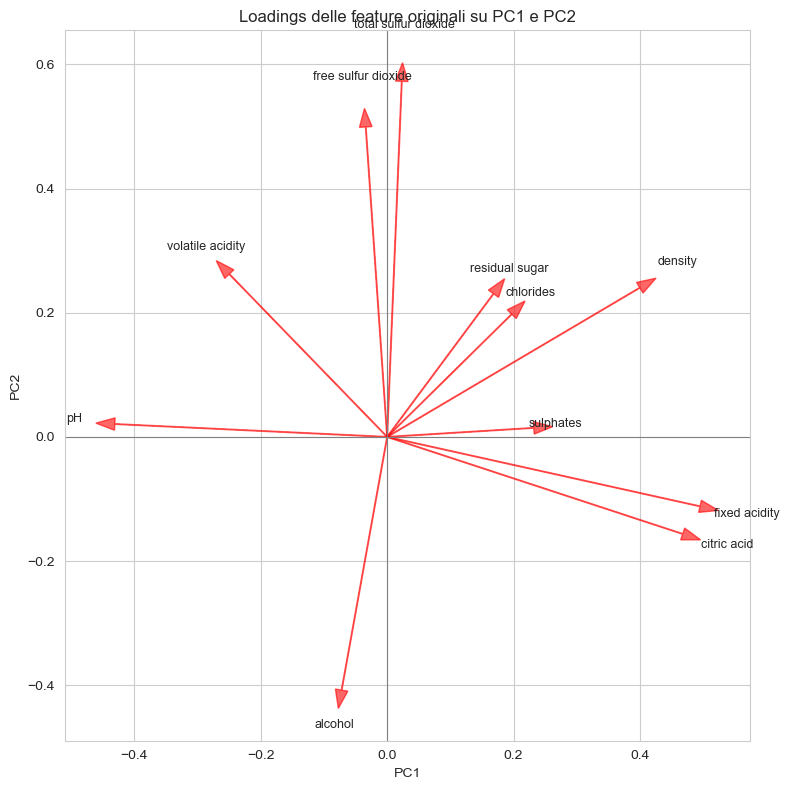

Miglior valore di k sul validation set: 16 (accuracy = 0.6562)


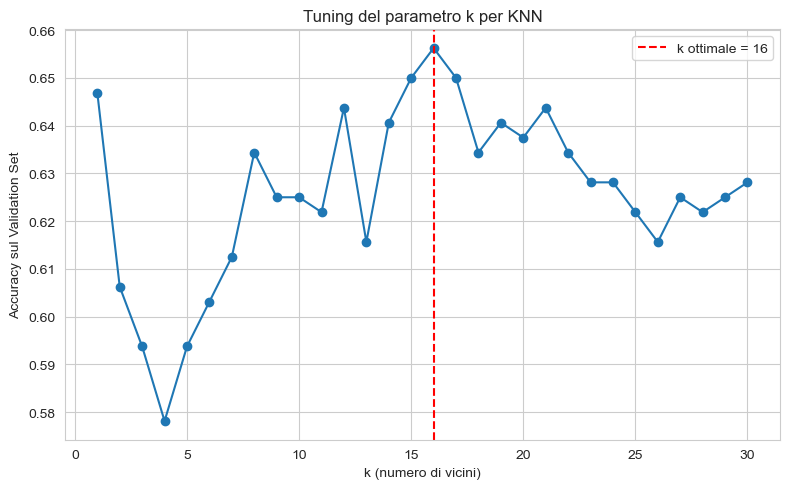

Miglior max_depth sul validation set: 8 (accuracy = 0.6406)


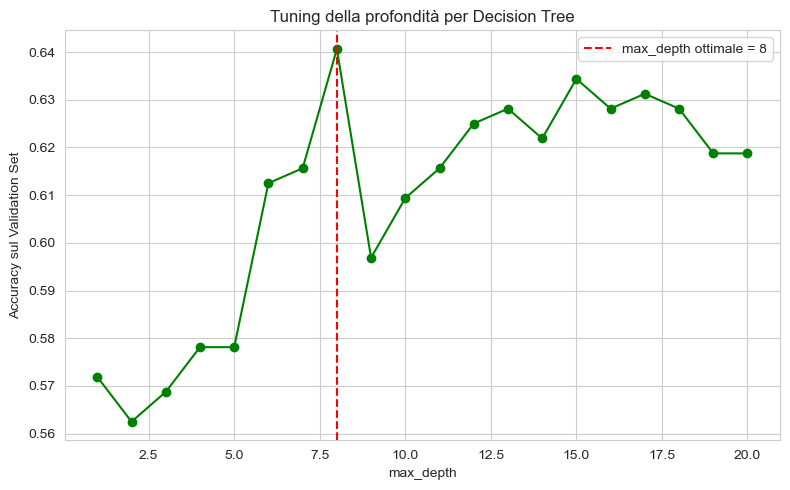

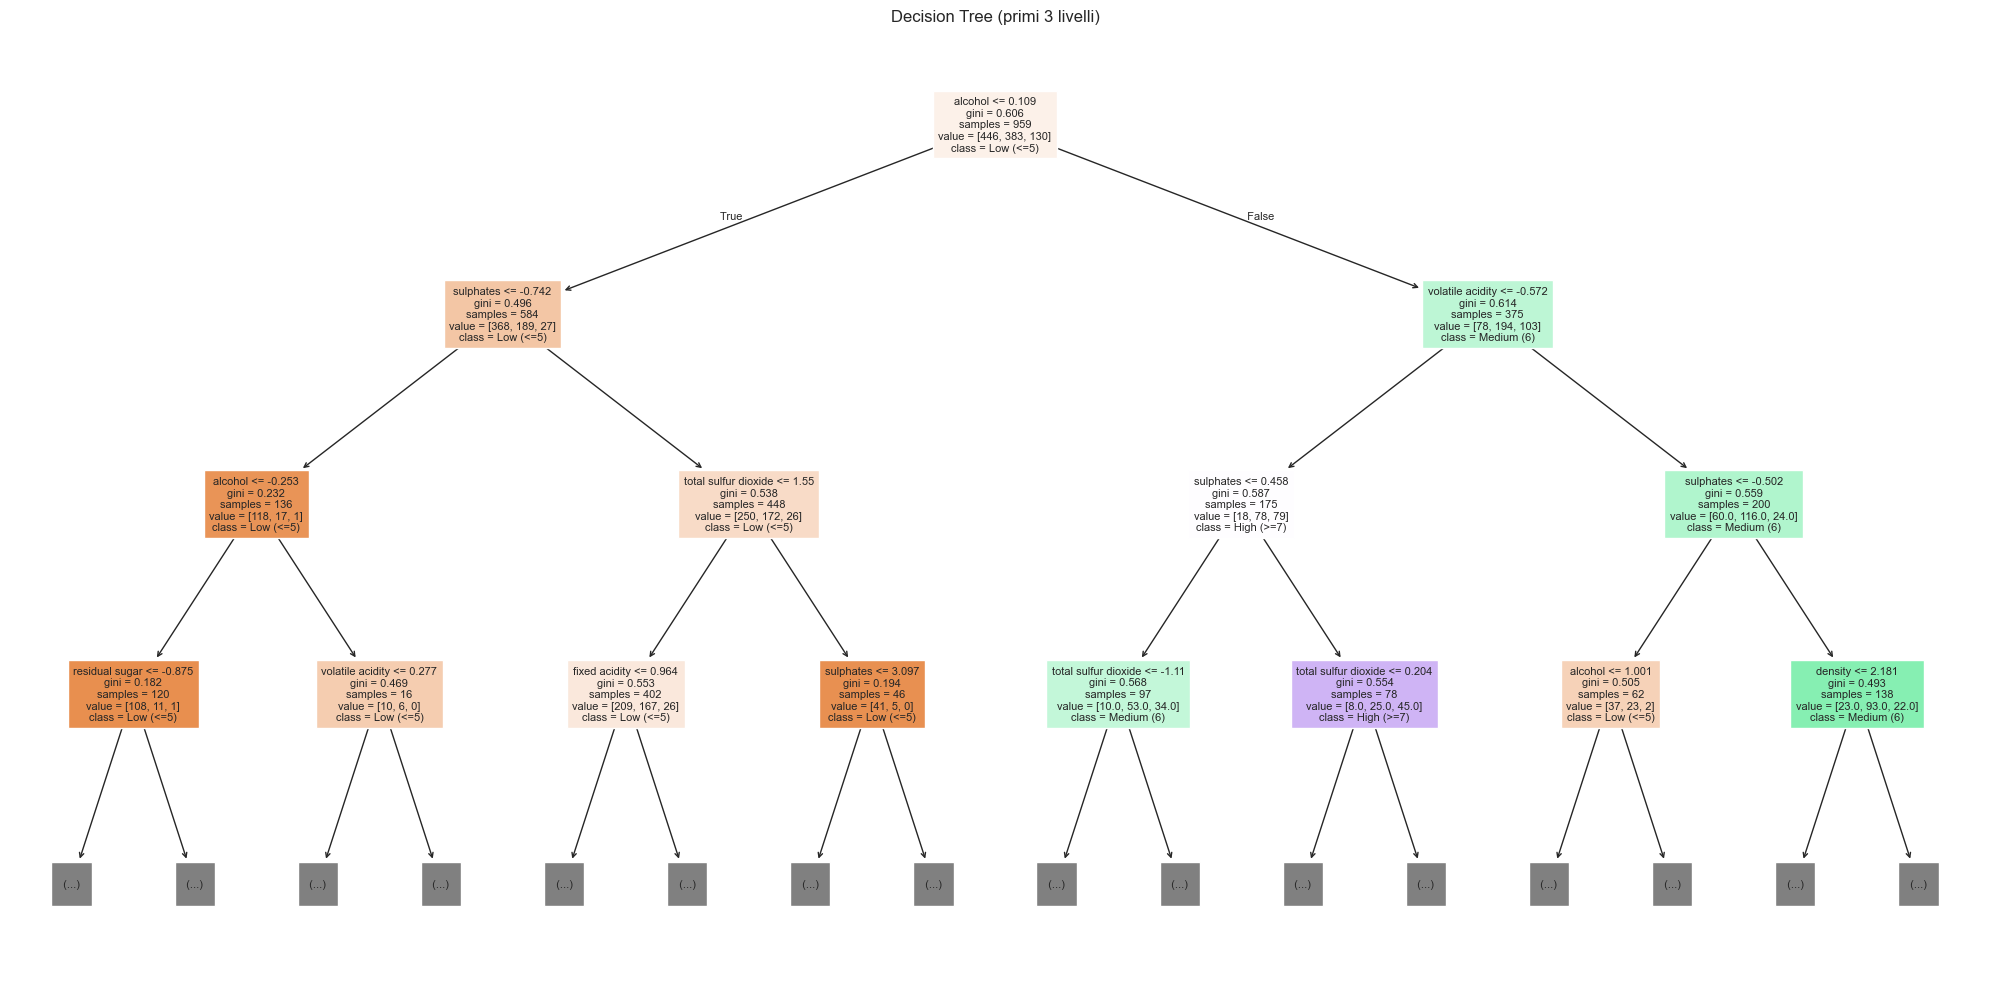

Miglior n_estimators sul validation set: 200 (accuracy = 0.7063)


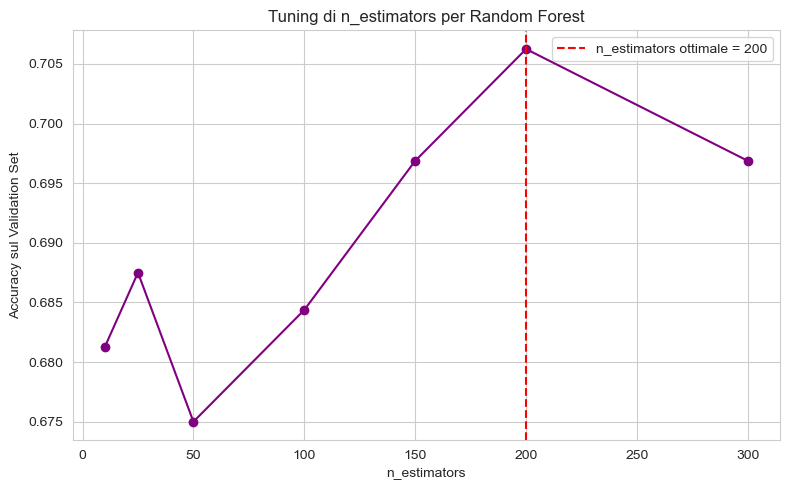

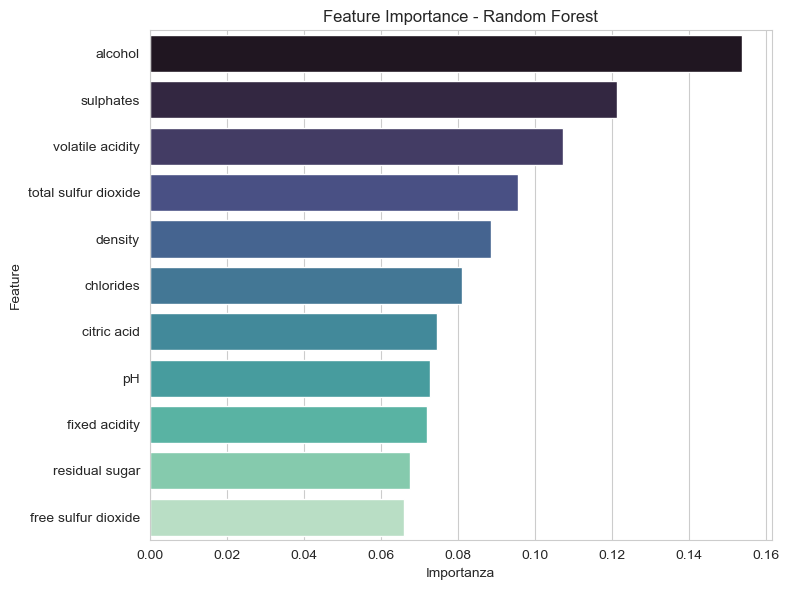

               Accuracy  Precision (macro)  Recall (macro)  F1-score (macro)  \
Modello                                                                        
KNN              0.6312             0.5917          0.5666            0.5756   
Decision Tree    0.5625             0.5276          0.5111            0.5174   
Random Forest    0.7250             0.6936          0.6726            0.6815   

               ROC AUC (macro, ovr)  
Modello                              
KNN                          0.7663  
Decision Tree                0.7143  
Random Forest                0.8779  


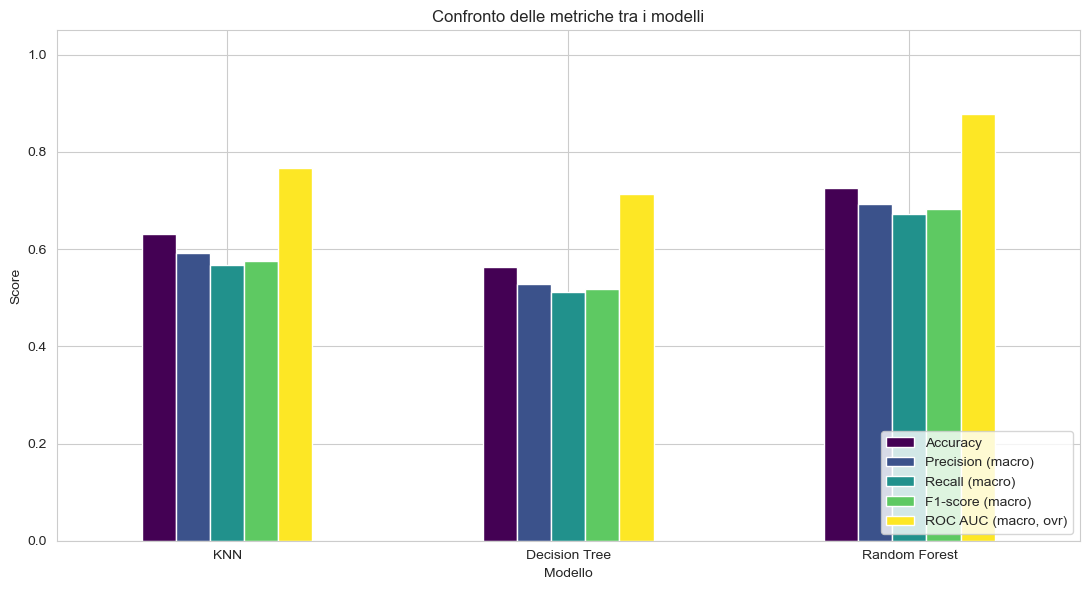


KNN
              precision    recall  f1-score   support

   Low (<=5)       0.71      0.77      0.74       149
  Medium (6)       0.57      0.56      0.56       128
  High (>=7)       0.50      0.37      0.43        43

    accuracy                           0.63       320
   macro avg       0.59      0.57      0.58       320
weighted avg       0.62      0.63      0.63       320


Decision Tree
              precision    recall  f1-score   support

   Low (<=5)       0.68      0.64      0.66       149
  Medium (6)       0.48      0.55      0.51       128
  High (>=7)       0.42      0.35      0.38        43

    accuracy                           0.56       320
   macro avg       0.53      0.51      0.52       320
weighted avg       0.57      0.56      0.56       320


Random Forest
              precision    recall  f1-score   support

   Low (<=5)       0.81      0.82      0.81       149
  Medium (6)       0.66      0.69      0.67       128
  High (>=7)       0.61      0.51      0

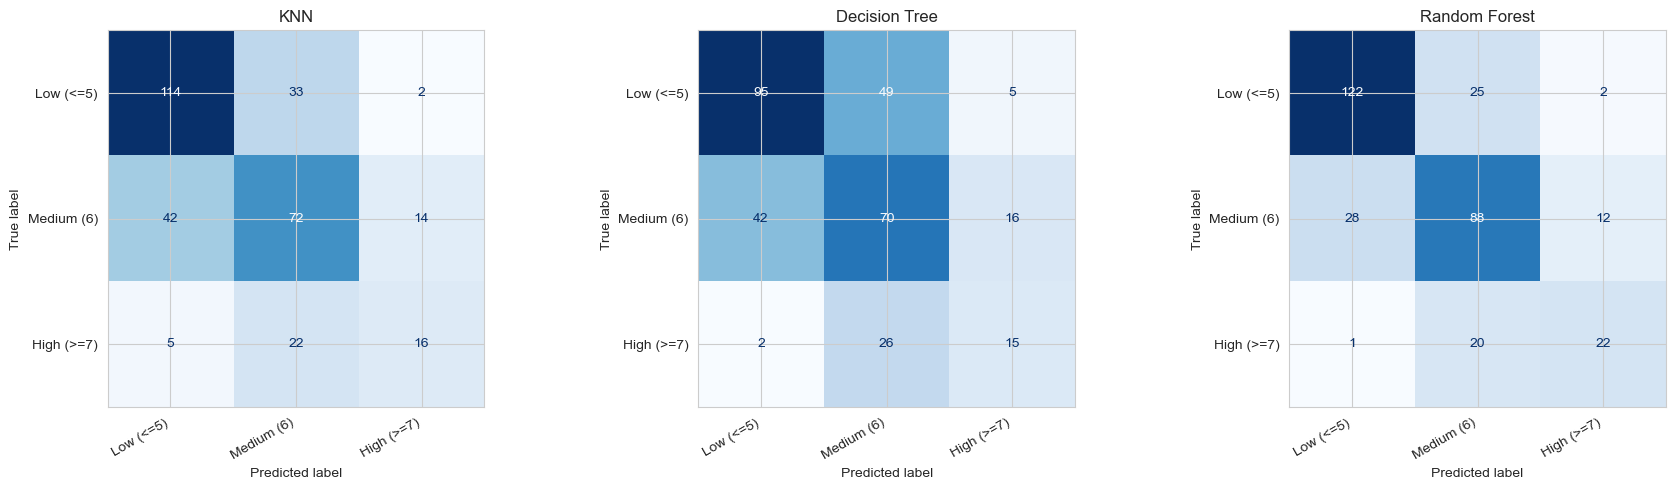

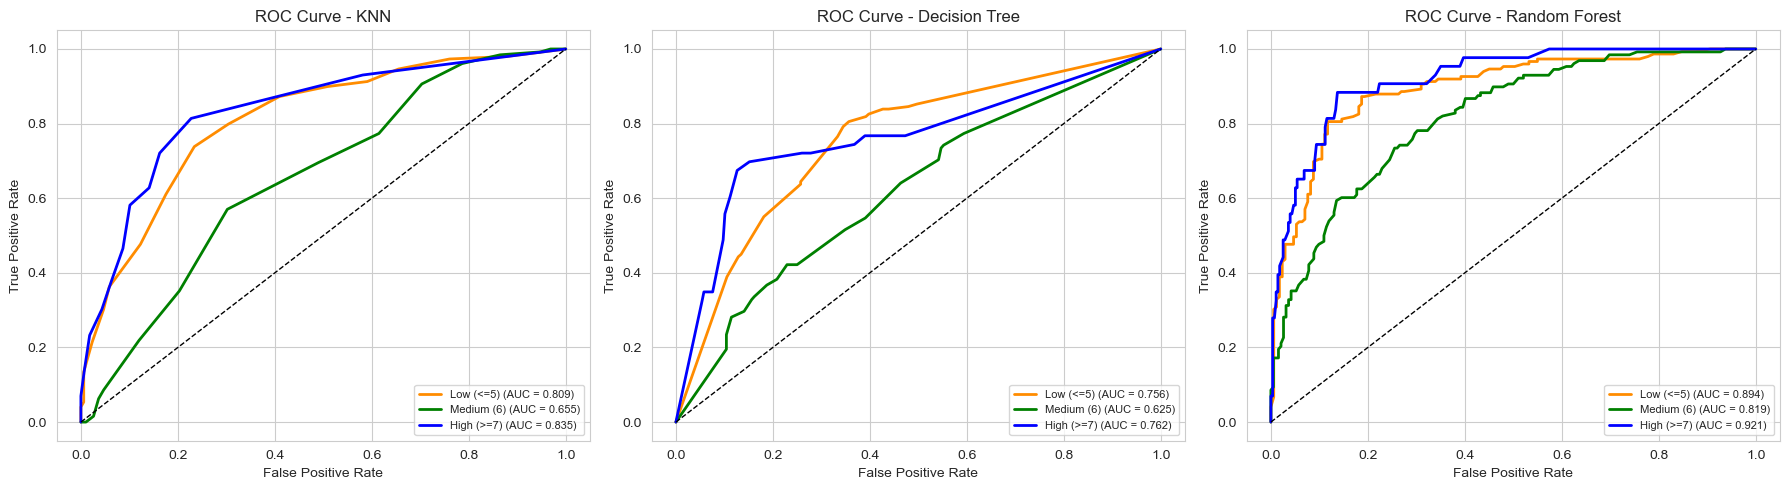

Modello scelto per la spiegabilità SHAP: Random Forest
Tipo di explainer usato: <class 'shap.explainers._tree.TreeExplainer'>
Numero di campioni spiegati: 200


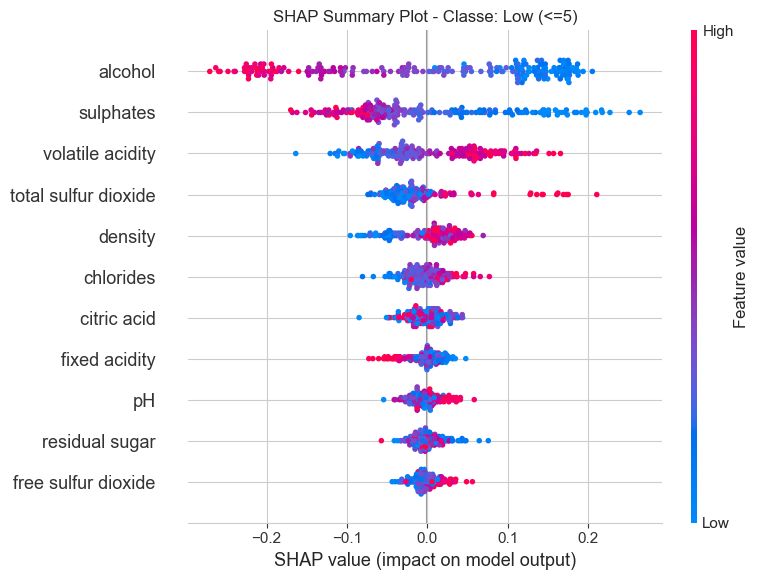

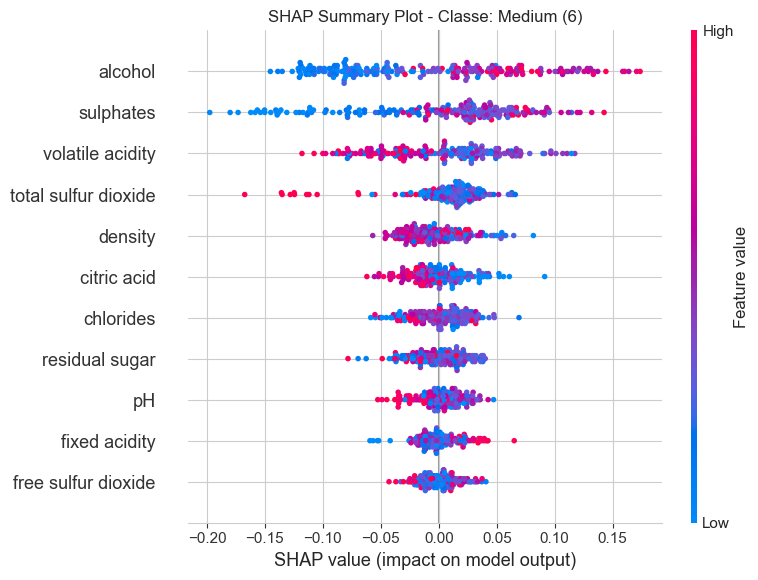

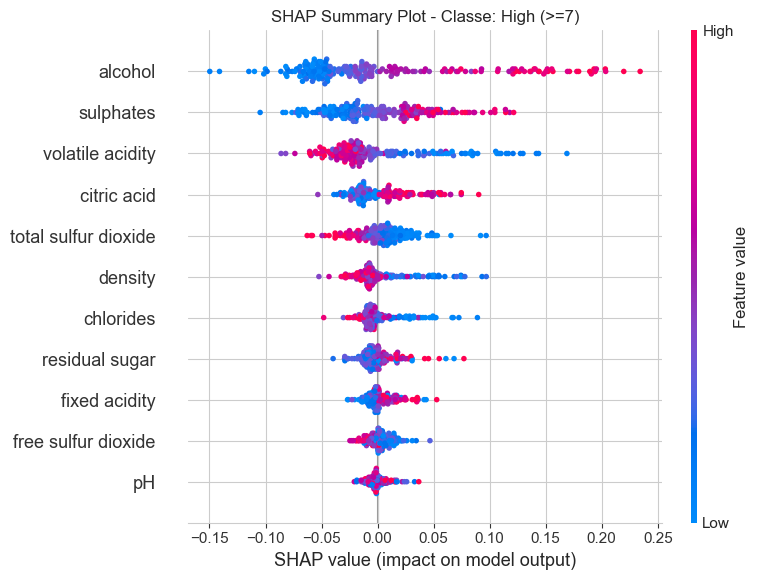

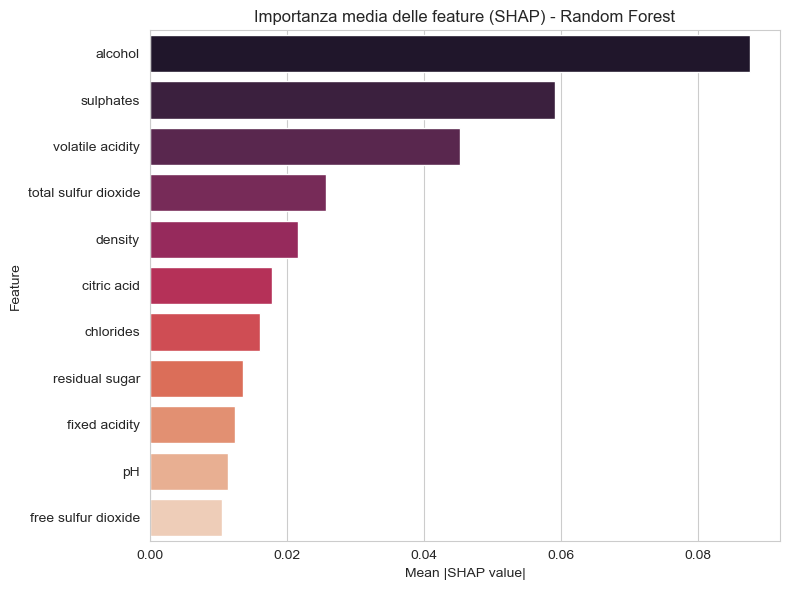

Riepilogo finale delle metriche sul test set:

               Accuracy  Precision (macro)  Recall (macro)  F1-score (macro)  \
Modello                                                                        
KNN              0.6312             0.5917          0.5666            0.5756   
Decision Tree    0.5625             0.5276          0.5111            0.5174   
Random Forest    0.7250             0.6936          0.6726            0.6815   

               ROC AUC (macro, ovr)  
Modello                              
KNN                          0.7663  
Decision Tree                0.7143  
Random Forest                0.8779  


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, classification_report
)

import shap

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=";")

print("Shape del dataset:", df.shape)
df.head()

df.info()


df.describe()

def quality_to_class(q):
    if q <= 5:
        return 0  # Low
    elif q == 6:
        return 1  # Medium
    else:
        return 2  # High

df["quality_class"] = df["quality"].apply(quality_to_class)

class_names = ["Low (<=5)", "Medium (6)", "High (>=7)"]

print(df["quality_class"].value_counts().sort_index())

plt.figure()
sns.countplot(x="quality_class", data=df, palette="viridis")
plt.xticks([0, 1, 2], class_names)
plt.title("Distribuzione delle classi target")
plt.xlabel("Classe")
plt.ylabel("Numero di campioni")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()


feature_cols = [c for c in df.columns if c not in ["quality", "quality_class"]]
X = df[feature_cols].values
y = df["quality_class"].values

print("Numero di feature:", len(feature_cols))
print("Feature:", feature_cols)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp
)

print("Train set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

explained_var = pca_full.explained_variance_ratio_
cum_explained_var = np.cumsum(explained_var)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(explained_var) + 1), explained_var, color="steelblue")
axes[0].set_xlabel("Componente Principale")
axes[0].set_ylabel("Varianza Spiegata")
axes[0].set_title("Varianza spiegata per componente")

axes[1].plot(range(1, len(cum_explained_var) + 1), cum_explained_var,
             marker="o", color="darkorange")
axes[1].axhline(y=0.95, color="red", linestyle="--", label="95% soglia")
axes[1].set_xlabel("Numero di Componenti")
axes[1].set_ylabel("Varianza Spiegata Cumulativa")
axes[1].set_title("Varianza spiegata cumulativa")
axes[1].legend()

plt.tight_layout()
plt.savefig("pca_explained_variance.png", dpi=150)
plt.show()

n_components_95 = np.argmax(cum_explained_var >= 0.95) + 1
print(f"Numero di componenti necessarie per spiegare il 95% della varianza: {n_components_95}")

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca2 = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_train_pca2[:, 0], X_train_pca2[:, 1],
    c=y_train, cmap="viridis", alpha=0.7, edgecolor="k", s=40
)
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varianza)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varianza)")
plt.title("Proiezione PCA 2D del training set (colorato per classe di qualità)")
legend1 = plt.legend(handles=scatter.legend_elements()[0], labels=class_names, title="Classe")
plt.gca().add_artist(legend1)
plt.tight_layout()
plt.savefig("pca_2d_scatter.png", dpi=150)
plt.show()


from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

pca_3d = PCA(n_components=3, random_state=RANDOM_STATE)
X_train_pca3 = pca_3d.fit_transform(X_train_scaled)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
p = ax.scatter(
    X_train_pca3[:, 0], X_train_pca3[:, 1], X_train_pca3[:, 2],
    c=y_train, cmap="viridis", alpha=0.7, edgecolor="k", s=40
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Proiezione PCA 3D del training set")
legend1 = ax.legend(handles=p.legend_elements()[0], labels=class_names, title="Classe")
ax.add_artist(legend1)
plt.tight_layout()
plt.savefig("pca_3d_scatter.png", dpi=150)
plt.show()

loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=["PC1", "PC2"],
    index=feature_cols
)

plt.figure(figsize=(8, 8))
for i, feature in enumerate(feature_cols):
    plt.arrow(0, 0, loadings.iloc[i, 0], loadings.iloc[i, 1],
              color="r", alpha=0.6, head_width=0.02)
    plt.text(loadings.iloc[i, 0] * 1.15, loadings.iloc[i, 1] * 1.15,
             feature, fontsize=9, ha="center")
plt.axhline(0, color="grey", linewidth=0.8)
plt.axvline(0, color="grey", linewidth=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Loadings delle feature originali su PC1 e PC2")
plt.tight_layout()
plt.savefig("pca_loadings.png", dpi=150)
plt.show()

loadings.sort_values("PC1", ascending=False)

k_values = range(1, 31)
val_accuracies = []

for k in k_values:
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    knn_tmp.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_val, knn_tmp.predict(X_val_scaled))
    val_accuracies.append(acc)

best_k = list(k_values)[np.argmax(val_accuracies)]
print(f"Miglior valore di k sul validation set: {best_k} (accuracy = {max(val_accuracies):.4f})")

plt.figure()
plt.plot(list(k_values), val_accuracies, marker="o")
plt.axvline(best_k, color="red", linestyle="--", label=f"k ottimale = {best_k}")
plt.xlabel("k (numero di vicini)")
plt.ylabel("Accuracy sul Validation Set")
plt.title("Tuning del parametro k per KNN")
plt.legend()
plt.tight_layout()
plt.savefig("knn_tuning.png", dpi=150)
plt.show()

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)


depth_values = range(1, 21)
val_accuracies_dt = []

for d in depth_values:
    dt_tmp = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    dt_tmp.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_val, dt_tmp.predict(X_val_scaled))
    val_accuracies_dt.append(acc)

best_depth = list(depth_values)[np.argmax(val_accuracies_dt)]
print(f"Miglior max_depth sul validation set: {best_depth} (accuracy = {max(val_accuracies_dt):.4f})")

plt.figure()
plt.plot(list(depth_values), val_accuracies_dt, marker="o", color="green")
plt.axvline(best_depth, color="red", linestyle="--", label=f"max_depth ottimale = {best_depth}")
plt.xlabel("max_depth")
plt.ylabel("Accuracy sul Validation Set")
plt.title("Tuning della profondità per Decision Tree")
plt.legend()
plt.tight_layout()
plt.savefig("dt_tuning.png", dpi=150)
plt.show()

dt_model = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE)
dt_model.fit(X_train_scaled, y_train)

plt.figure(figsize=(20, 10))
plot_tree(dt_model, max_depth=3, feature_names=feature_cols,
          class_names=class_names, filled=True, fontsize=8)
plt.title("Decision Tree (primi 3 livelli)")
plt.tight_layout()
plt.savefig("decision_tree_plot.png", dpi=150)
plt.show()


n_estimators_values = [10, 25, 50, 100, 150, 200, 300]
val_accuracies_rf = []

for n in n_estimators_values:
    rf_tmp = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE)
    rf_tmp.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_val, rf_tmp.predict(X_val_scaled))
    val_accuracies_rf.append(acc)

best_n_estimators = n_estimators_values[np.argmax(val_accuracies_rf)]
print(f"Miglior n_estimators sul validation set: {best_n_estimators} (accuracy = {max(val_accuracies_rf):.4f})")

plt.figure()
plt.plot(n_estimators_values, val_accuracies_rf, marker="o", color="purple")
plt.axvline(best_n_estimators, color="red", linestyle="--",
            label=f"n_estimators ottimale = {best_n_estimators}")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy sul Validation Set")
plt.title("Tuning di n_estimators per Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig("rf_tuning.png", dpi=150)
plt.show()

rf_model = RandomForestClassifier(n_estimators=best_n_estimators, random_state=RANDOM_STATE)
rf_model.fit(X_train_scaled, y_train)

importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, palette="mako")
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importanza")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=150)
plt.show()

models = {
    "KNN": knn_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")

    results.append({
        "Modello": name,
        "Accuracy": acc,
        "Precision (macro)": prec,
        "Recall (macro)": rec,
        "F1-score (macro)": f1,
        "ROC AUC (macro, ovr)": roc_auc
    })

results_df = pd.DataFrame(results).set_index("Modello")
results_df = results_df.round(4)
print(results_df)

results_df.plot(kind="bar", figsize=(11, 6), colormap="viridis")
plt.title("Confronto delle metriche tra i modelli")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig("metrics_comparison.png", dpi=150)
plt.show()

for name, model in models.items():
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    y_pred = model.predict(X_test_scaled)
    labels_present = sorted(set(y_test) | set(y_pred))
    target_names_present = [class_names[i] for i in labels_present]
    print(classification_report(
        y_test, y_pred, labels=labels_present,
        target_names=target_names_present, zero_division=0
    ))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
    ax.set_xticklabels(class_names, rotation=30, ha="right")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()


y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ["darkorange", "green", "blue"]

for ax, (name, model) in zip(axes, models.items()):
    y_proba = model.predict_proba(X_test_scaled)

    for i, color in zip(range(n_classes), colors):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f"{class_names[i]} (AUC = {roc_auc_val:.3f})")

    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC Curve - {name}")
    ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()

best_model_name = results_df["F1-score (macro)"].idxmax()
best_model = models[best_model_name]
print(f"Modello scelto per la spiegabilità SHAP: {best_model_name}")

if best_model_name in ["Decision Tree", "Random Forest"]:
    X_test_sample = X_test_scaled[:200]
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_sample)
else:
    X_test_sample = X_test_scaled[:30]
    background = shap.kmeans(X_train_scaled, 20)  
    explainer = shap.KernelExplainer(best_model.predict_proba, background)
    shap_values = explainer.shap_values(X_test_sample, nsamples=100)

print("Tipo di explainer usato:", type(explainer))
print("Numero di campioni spiegati:", X_test_sample.shape[0])


if isinstance(shap_values, list):
    shap_values_for_plot = shap_values
else:
    shap_values_for_plot = [shap_values[:, :, c] for c in range(shap_values.shape[2])]

for class_idx, class_label in enumerate(class_names):
    plt.figure()
    shap.summary_plot(
        shap_values_for_plot[class_idx],
        X_test_sample,
        feature_names=feature_cols,
        show=False
    )
    plt.title(f"SHAP Summary Plot - Classe: {class_label}")
    plt.tight_layout()
    plt.savefig(f"shap_summary_class_{class_idx}.png", dpi=150, bbox_inches="tight")
    plt.show()

mean_abs_shap = np.mean(
    [np.abs(sv).mean(axis=0) for sv in shap_values_for_plot], axis=0
)
shap_importance = pd.Series(mean_abs_shap, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=shap_importance.values, y=shap_importance.index, palette="rocket")
plt.title(f"Importanza media delle feature (SHAP) - {best_model_name}")
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("shap_global_importance.png", dpi=150)
plt.show()

print("Riepilogo finale delle metriche sul test set:\n")
print(results_df)